# 단변량 LSTM 전력 수요 예측 (기준 모델)

전력 사용량(`평균`, kW) **하나만** 입력으로 사용해 다음 1시간의 전력을 예측하는 가장 단순한 LSTM이다.
다변량 모델(`LSTM_AIModel`)과 비교하기 위한 기준선(baseline)으로 사용한다.

- **입력**: `okm_augumented_2021_processed.xlsx`
- **입력 시퀀스**: 직전 24시간의 `평균` → 다음 1시간 `평균` 예측
- **분할**: 시간 순서 기준 학습 85% / 테스트 15%
- **평가 지표**: RMSE · MAE · R²

## 0. 라이브러리 설치 및 임포트

In [1]:
# 필요 시 주석 해제 후 실행
# !pip install tensorflow-cpu scikit-learn pandas openpyxl joblib

In [9]:
import os
import time
import numpy as np
import pandas as pd

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # TensorFlow 불필요 로그 숨김

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (설치된 나눔고딕 / Noto Sans CJK / 맑은 고딕 중 첫 번째 사용)
def _set_korean_font():
    candidates = [f.fname for f in fm.fontManager.ttflist
                  if ("NanumGothic" in f.fname) or ("NotoSansCJK" in f.fname) or ("Malgun" in f.fname)]
    if candidates:
        fm.fontManager.addfont(candidates[0])
        plt.rcParams["font.family"] = fm.FontProperties(fname=candidates[0]).get_name()
    plt.rcParams["axes.unicode_minus"] = False

_set_korean_font()
print("TensorFlow 버전:", tf.__version__)

TensorFlow 버전: 2.17.0


## 1. 설정값

In [3]:
SEED = 42
SEQ_LEN = 24               # 입력 시퀀스 길이(시간)
TRAIN_RATIO = 0.85         # 학습 데이터 비율
EPOCHS = 50
BATCH_SIZE = 32

TARGET_COL = "평균"         # 예측 대상: 시간 평균 전력(kW)
DATA_PATH = "okm_augumented_2021_processed.xlsx"
OUT_DIR = "."

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. 데이터 불러오기

In [4]:
df = pd.read_excel(DATA_PATH)
df = df.sort_values("datetime").reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"전체 데이터 크기: {df.shape}")
print(f"기간: {df['datetime'].min()} ~ {df['datetime'].max()}")
display(df.head())

전체 데이터 크기: (6168, 24)
기간: 2021-01-01 00:00:00 ~ 2021-09-14 23:00:00


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,...,d,m,공장인원,인건비,시간복원,datetime,전력 구간합계,전력 최대값,전력 최소값,전력 변동폭
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,...,1,1,0.0,1.5,0,2021-01-01 00:00:00,245,62,61,1
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,...,1,1,0.0,1.5,0,2021-01-01 01:00:00,418,116,93,23
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,...,1,1,0.0,1.5,0,2021-01-01 02:00:00,415,107,96,11
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,...,1,1,0.0,1.5,0,2021-01-01 03:00:00,421,110,92,18
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,...,1,1,0.0,1.5,0,2021-01-01 04:00:00,427,108,105,3


## 3. 시퀀스 생성 및 정규화
- 스케일러는 **학습 구간으로만** fit 해 데이터 누수를 막는다.
- 직전 `SEQ_LEN`(24)시간 → 다음 1시간 형태의 시퀀스를 만든다.

In [5]:
def make_sequences(data: np.ndarray, seq_len: int):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, dtype="float32")[..., np.newaxis], np.array(y, dtype="float32")

# 예측 대상 컬럼만 사용 (단변량)
raw_data = df[TARGET_COL].values.astype("float32")

# 학습/테스트 분할 지점
train_size = int(len(raw_data) * TRAIN_RATIO)

# 데이터 누수 방지: 학습 구간으로만 스케일러 fit
scaler = MinMaxScaler()
train_data = raw_data[:train_size].reshape(-1, 1)
scaler.fit(train_data)

# 전체 구간 스케일 변환
scaled_data = scaler.transform(raw_data.reshape(-1, 1)).flatten()

# 시퀀스 생성
X, y = make_sequences(scaled_data, SEQ_LEN)

# 학습/테스트 분리 (테스트 첫 타깃 = train_size 시점)
split_idx = train_size - SEQ_LEN
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

print(f"학습 입력 형태 (X_train): {X_train.shape}")
print(f"테스트 입력 형태 (X_test): {X_test.shape}")

학습 입력 형태 (X_train): (5218, 24, 1)
테스트 입력 형태 (X_test): (926, 24, 1)


## 4. 모델 정의
`LSTM(64) → Dropout(0.2) → LSTM(32) → Dense(16) → Dense(1)`

In [6]:
model = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

I0000 00:00:1790600437.256945   62530 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1790600437.346269   62530 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1790600437.346814   62530 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1790600437.372803   62530 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 모델 학습

In [7]:
es = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[es],
    verbose=1
)
print(f"학습 소요 시간: {time.time() - start_time:.1f}초")

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0638 - val_loss: 0.0210
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0231 - val_loss: 0.0182
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0206 - val_loss: 0.0157
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0187 - val_loss: 0.0143
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0175 - val_loss: 0.0138
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0168 - val_loss: 0.0138
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0161 - val_loss: 0.0135
Epoch 8/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0157 - val_loss: 0.0136
Epoch 9/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0153 - val_loss: 0.0134
Epoch 10/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0148 - val_loss: 0.0128
Epoch 11/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0144 - val_loss: 0.0133
Epoch 12/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

Epoch 2/60


147/147 - 2s - 15ms/step - loss: 0.0223 - val_loss: 0.0212


Epoch 3/60


147/147 - 3s - 18ms/step - loss: 0.0193 - val_loss: 0.0234


...

Epoch 15/60


147/147 - 3s - 18ms/step - loss: 0.0094 - val_loss: 0.0183


Epoch 16/60


147/147 - 3s - 17ms/step - loss: 0.0089 - val_loss: 0.0195


학습 완료 (소요 시간: 42.1초, 총 에폭: 16)


## 6. 예측 및 성능 평가

In [10]:
# 예측
y_pred_scaled = model.predict(X_test)

# 원래 단위(kW)로 역변환
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred_scaled)

# 평가 지표 계산
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"[테스트 결과 평가]")
print(f"- RMSE: {rmse:.4f}")
print(f"- MAE:  {mae:.4f}")
print(f"- R2 Score: {r2:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[테스트 결과 평가]
- RMSE: 13.5944
- MAE:  10.0294
- R2 Score: 0.9461


## 7. 결과 시각화

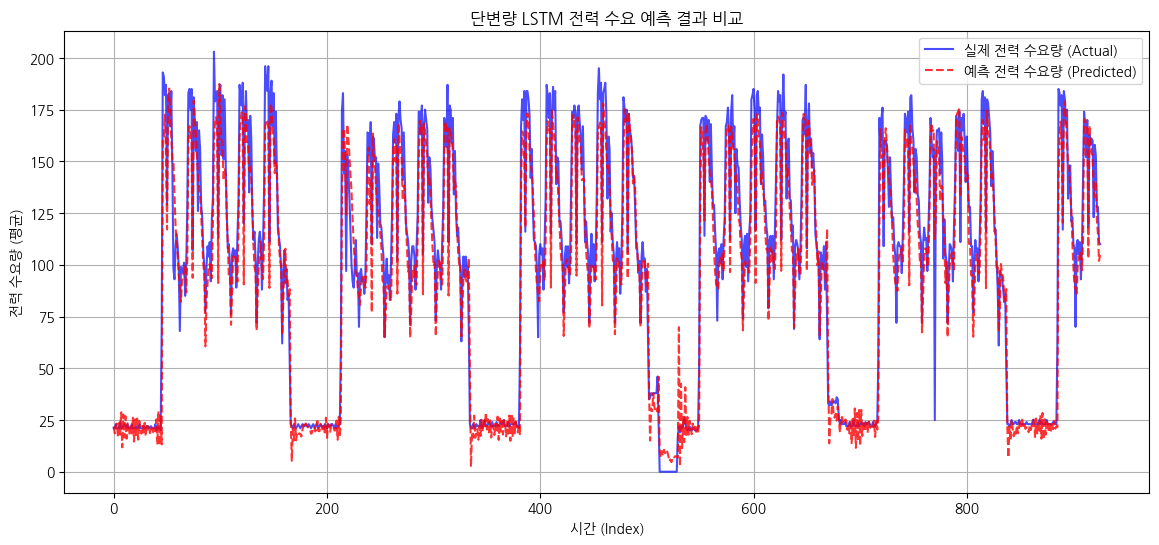

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv, label="실제 전력 수요량 (Actual)", color="blue", alpha=0.7)
plt.plot(y_pred_inv, label="예측 전력 수요량 (Predicted)", color="red", linestyle="--", alpha=0.8)
plt.title("단변량 LSTM 전력 수요 예측 결과 비교")
plt.xlabel("시간 (Index)")
plt.ylabel("전력 수요량 (평균)")
plt.legend()
plt.grid(True)
plt.show()